# Core Exploratory Data Analysis

Covers all five EDA checklist items:
1. Dataset overview (shape, dtypes, memory, rows per search)
2. Target analysis (click rate, booking rate, searches with zero bookings)
3. Feature distributions (histograms, summary stats, value counts)
4. Feature vs. target relationships (star rating, brand, promotion, price vs. booking rate)
5. Correlation matrix of numeric features with click_bool and booking_bool

In [1]:
import sys
from pathlib import Path

cwd = Path(".").resolve()
REPO_ROOT = cwd if (cwd / ".git").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import load_train

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

df = load_train()
print(f"{len(df):,} rows, {df['srch_id'].nunique():,} searches, {df.shape[1]} columns")

4,958,347 rows, 199,795 searches, 54 columns


## 1. Dataset Overview

In [2]:
# Shape and dtypes
print("Shape:", df.shape)
print("\nDtype counts:")
print(df.dtypes.value_counts())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Shape: (4958347, 54)

Dtype counts:
float32    34
int8       13
int32       3
int16       3
str         1
Name: count, dtype: int64

Memory usage: 0.96 GB


Hotels per search:
count    199795.000000
mean         24.817173
std           9.113335
min           5.000000
25%          18.000000
50%          29.000000
75%          32.000000
max          38.000000
dtype: float64


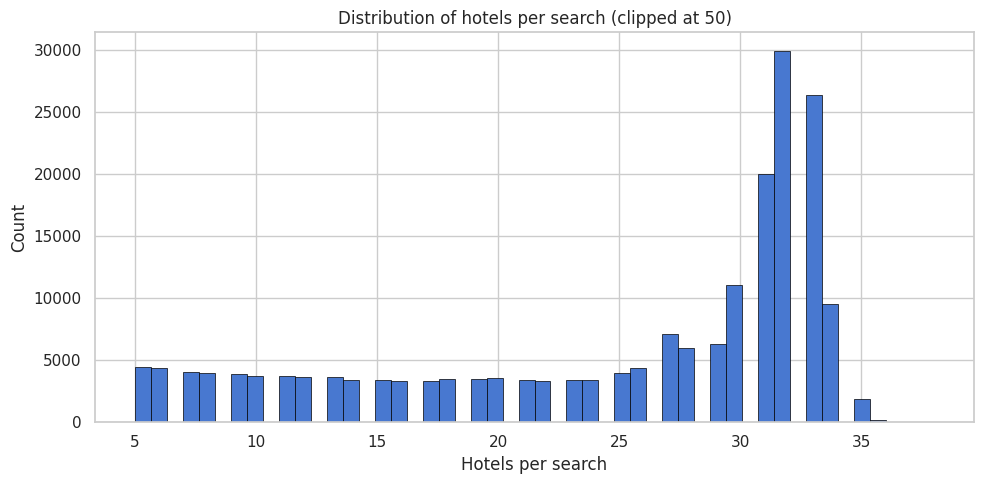

In [3]:
# Hotels per search
hotels_per_search = df.groupby("srch_id").size()
print("Hotels per search:")
print(hotels_per_search.describe())

fig, ax = plt.subplots()
hotels_per_search.clip(upper=50).hist(bins=50, ax=ax, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Hotels per search")
ax.set_ylabel("Count")
ax.set_title("Distribution of hotels per search (clipped at 50)")
plt.tight_layout()
plt.show()

In [4]:
# Unique counts for key ID columns
id_cols = ["prop_id", "srch_destination_id", "site_id", "prop_country_id", "visitor_location_country_id"]
print("Unique counts:")
for col in id_cols:
    print(f"  {col}: {df[col].nunique():,}")

Unique counts:
  prop_id: 129,113
  srch_destination_id: 18,127
  site_id: 34
  prop_country_id: 172
  visitor_location_country_id: 210


The dataset contains ~5M hotel-search pair rows across ~200K unique searches. Each search surfaces 5–38 candidate hotels (median 29). Memory footprint is under 1 GB with optimized dtypes. The search space spans 26 sites, 172 hotel countries, and 33K unique destinations — a highly heterogeneous marketplace.

## 2. Target Variable Analysis

In [5]:
click_rate = df["click_bool"].mean()
booking_rate = df["booking_bool"].mean()
booking_given_click = df.loc[df["click_bool"] == 1, "booking_bool"].mean()

print(f"Overall click rate:    {click_rate:.4f} ({click_rate*100:.2f}%)")
print(f"Overall booking rate:  {booking_rate:.4f} ({booking_rate*100:.2f}%)")
print(f"P(booking | click):    {booking_given_click:.4f} ({booking_given_click*100:.2f}%)")

Overall click rate:    0.0447 (4.47%)
Overall booking rate:  0.0279 (2.79%)
P(booking | click):    0.6237 (62.37%)


In [6]:
# Sanity check: every booking should also be a click
booking_no_click = ((df["booking_bool"] == 1) & (df["click_bool"] == 0)).sum()
print(f"Bookings without a click: {booking_no_click} (should be 0)")
print("\nCross-tab (click vs booking):")
print(pd.crosstab(df["click_bool"], df["booking_bool"], margins=True))

Bookings without a click: 0 (should be 0)

Cross-tab (click vs booking):
booking_bool        0       1      All
click_bool                            
0             4736468       0  4736468
1               83489  138390   221879
All           4819957  138390  4958347


Clicks per search:
count    199795.000000
mean          1.110533
std           0.563393
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          25.000000
Name: click_bool, dtype: float64

Searches with zero clicks:   0.0000 (0.0%)
Searches with zero bookings: 0.3073 (30.7%)


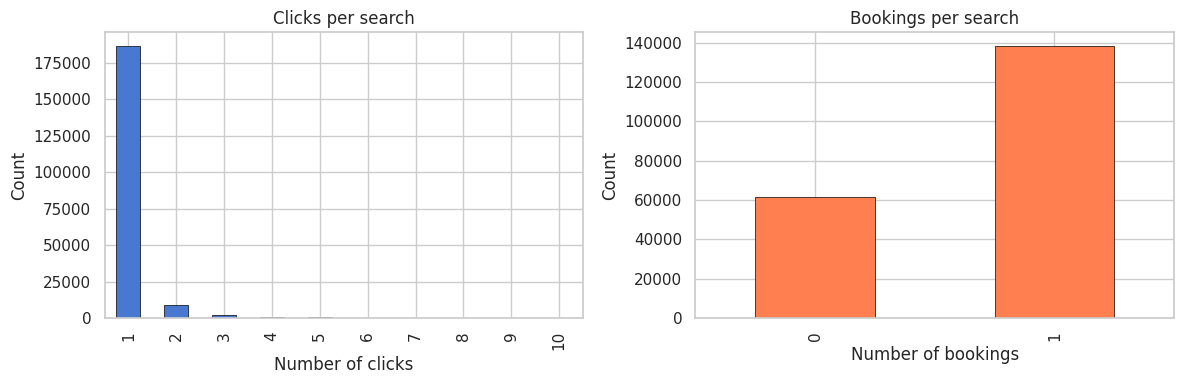

In [7]:
# Clicks and bookings per search
clicks_per_search = df.groupby("srch_id")["click_bool"].sum()
bookings_per_search = df.groupby("srch_id")["booking_bool"].sum()

print("Clicks per search:")
print(clicks_per_search.describe())
print(f"\nSearches with zero clicks:   {(clicks_per_search == 0).mean():.4f} ({(clicks_per_search == 0).mean()*100:.1f}%)")
print(f"Searches with zero bookings: {(bookings_per_search == 0).mean():.4f} ({(bookings_per_search == 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
clicks_per_search.clip(upper=10).value_counts().sort_index().plot.bar(ax=axes[0], edgecolor="black", linewidth=0.5)
axes[0].set_title("Clicks per search")
axes[0].set_xlabel("Number of clicks")
axes[0].set_ylabel("Count")

bookings_per_search.clip(upper=5).value_counts().sort_index().plot.bar(ax=axes[1], edgecolor="black", linewidth=0.5, color="coral")
axes[1].set_title("Bookings per search")
axes[1].set_xlabel("Number of bookings")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Extreme class imbalance: only 2.79% of rows are bookings, 4.47% are clicks. However, 62.4% of clicks lead to a booking — so the real challenge is predicting which hotel gets clicked, not whether a click converts. Every booking is confirmed as also being a click (zero exceptions). Most searches produce exactly 0 or 1 booking.

## 3. Feature Distributions

### Price Features

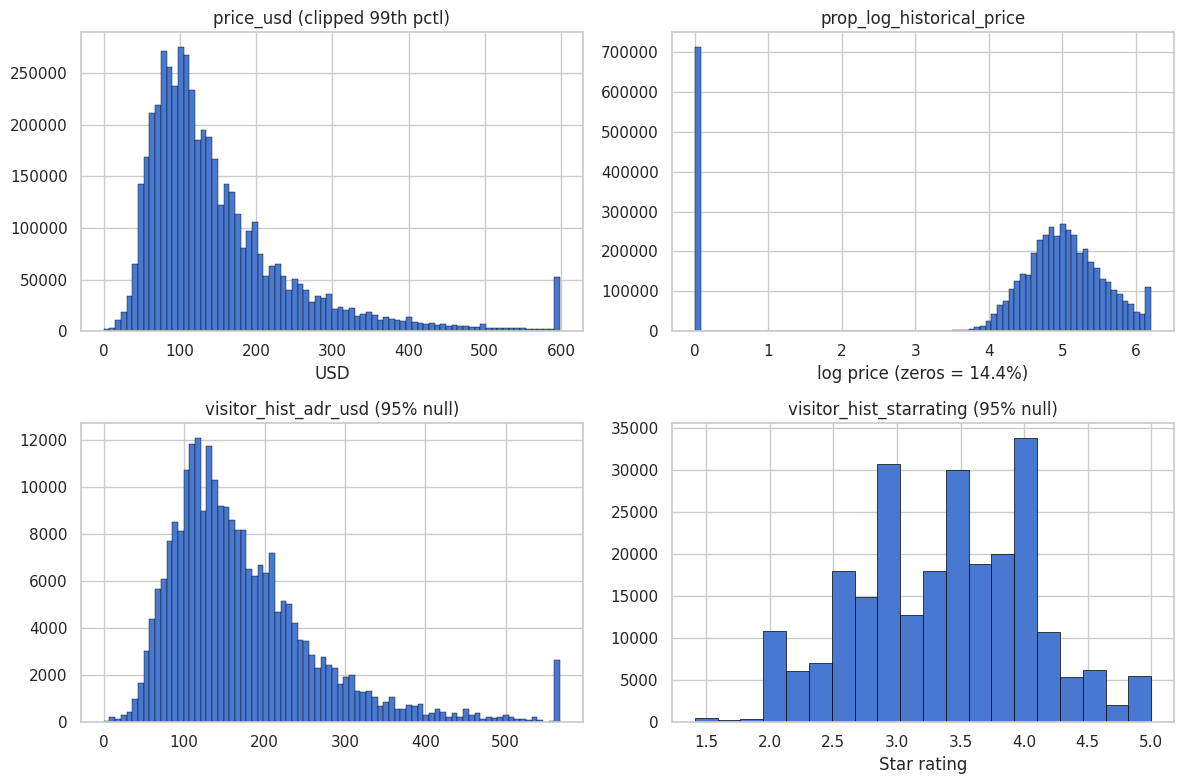

price_usd summary:
count    4.958347e+06
mean     2.542096e+02
std      1.600124e+04
min      0.000000e+00
25%      8.500000e+01
50%      1.220000e+02
75%      1.849600e+02
max      1.972633e+07
Name: price_usd, dtype: float64


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# price_usd
df["price_usd"].clip(upper=df["price_usd"].quantile(0.99))\
    .hist(bins=80, ax=axes[0], edgecolor="black", linewidth=0.3)
axes[0].set_title("price_usd (clipped 99th pctl)")
axes[0].set_xlabel("USD")

# prop_log_historical_price
df["prop_log_historical_price"]\
    .hist(bins=80, ax=axes[1], edgecolor="black", linewidth=0.3)
axes[1].set_title("prop_log_historical_price")
zero_hist = (df["prop_log_historical_price"] == 0).mean()
axes[1].set_xlabel(f"log price (zeros = {zero_hist*100:.1f}%)")

# visitor_hist_adr_usd
visitor_hist = df["visitor_hist_adr_usd"].dropna()
visitor_hist.clip(upper=visitor_hist.quantile(0.99))\
    .hist(bins=80, ax=axes[2], edgecolor="black", linewidth=0.3)
null_pct = df["visitor_hist_adr_usd"].isnull().mean()
axes[2].set_title(f"visitor_hist_adr_usd ({null_pct*100:.0f}% null)")

# visitor_hist_starrating
df["visitor_hist_starrating"].dropna()\
    .hist(bins=20, ax=axes[3], edgecolor="black", linewidth=0.5)
null_pct_star = df["visitor_hist_starrating"].isnull().mean()
axes[3].set_title(f"visitor_hist_starrating ({null_pct_star*100:.0f}% null)")
axes[3].set_xlabel("Star rating")

plt.tight_layout()
plt.show()

print("price_usd summary:")
print(df["price_usd"].describe())

### Hotel Quality Features

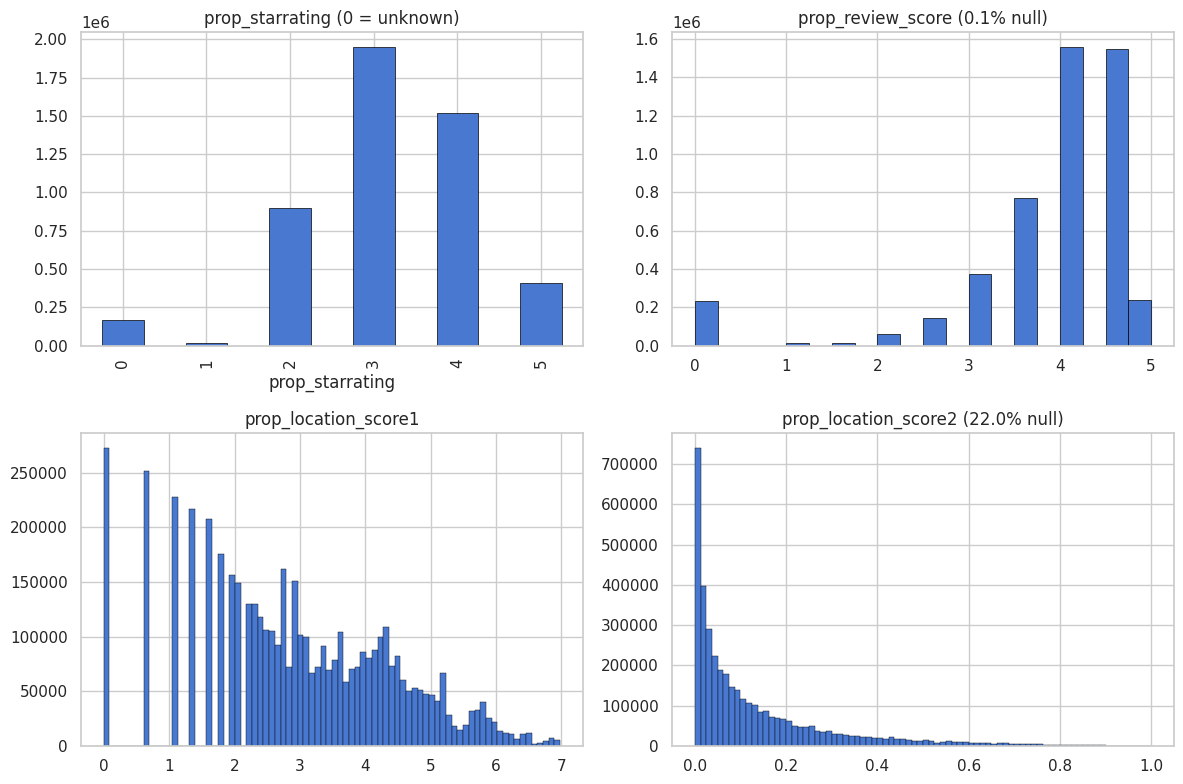

prop_brand_bool value counts:
prop_brand_bool
1    3147060
0    1811287
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# prop_starrating
df["prop_starrating"].value_counts().sort_index().plot.bar(ax=axes[0, 0], edgecolor="black", linewidth=0.5)
axes[0, 0].set_title("prop_starrating (0 = unknown)")

# prop_review_score
df["prop_review_score"].dropna().hist(bins=20, ax=axes[0, 1], edgecolor="black", linewidth=0.5)
axes[0, 1].set_title(f"prop_review_score ({df['prop_review_score'].isnull().mean()*100:.1f}% null)")

# prop_location_score1
df["prop_location_score1"].hist(bins=80, ax=axes[1, 0], edgecolor="black", linewidth=0.3)
axes[1, 0].set_title("prop_location_score1")

# prop_location_score2
df["prop_location_score2"].dropna().hist(bins=80, ax=axes[1, 1], edgecolor="black", linewidth=0.3)
axes[1, 1].set_title(f"prop_location_score2 ({df['prop_location_score2'].isnull().mean()*100:.1f}% null)")

plt.tight_layout()
plt.show()

# prop_brand_bool
print("prop_brand_bool value counts:")
print(df["prop_brand_bool"].value_counts())

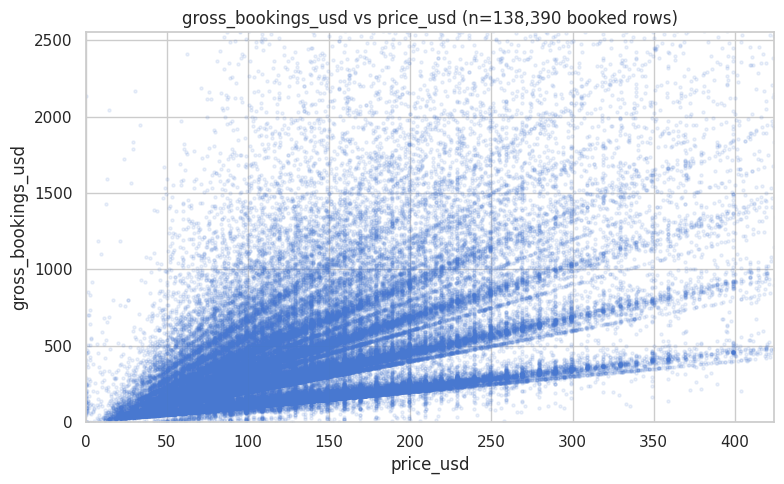

price_usd summary:
count    4.958347e+06
mean     2.542096e+02
std      1.600124e+04
min      0.000000e+00
25%      8.500000e+01
50%      1.220000e+02
75%      1.849600e+02
max      1.972633e+07
Name: price_usd, dtype: float64


In [10]:
# gross_bookings_usd vs price_usd (booked rows only)
booked = df[df["booking_bool"] == 1][["price_usd", "gross_bookings_usd"]].dropna()
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(booked["price_usd"], booked["gross_bookings_usd"], alpha=0.1, s=5)
ax.set_xlabel("price_usd")
ax.set_ylabel("gross_bookings_usd")
ax.set_title(f"gross_bookings_usd vs price_usd (n={len(booked):,} booked rows)")
ax.set_xlim(0, booked["price_usd"].quantile(0.99))
ax.set_ylim(0, booked["gross_bookings_usd"].quantile(0.99))
plt.tight_layout()
plt.show()

print("price_usd summary:")
print(df["price_usd"].describe())

### Search Context Features

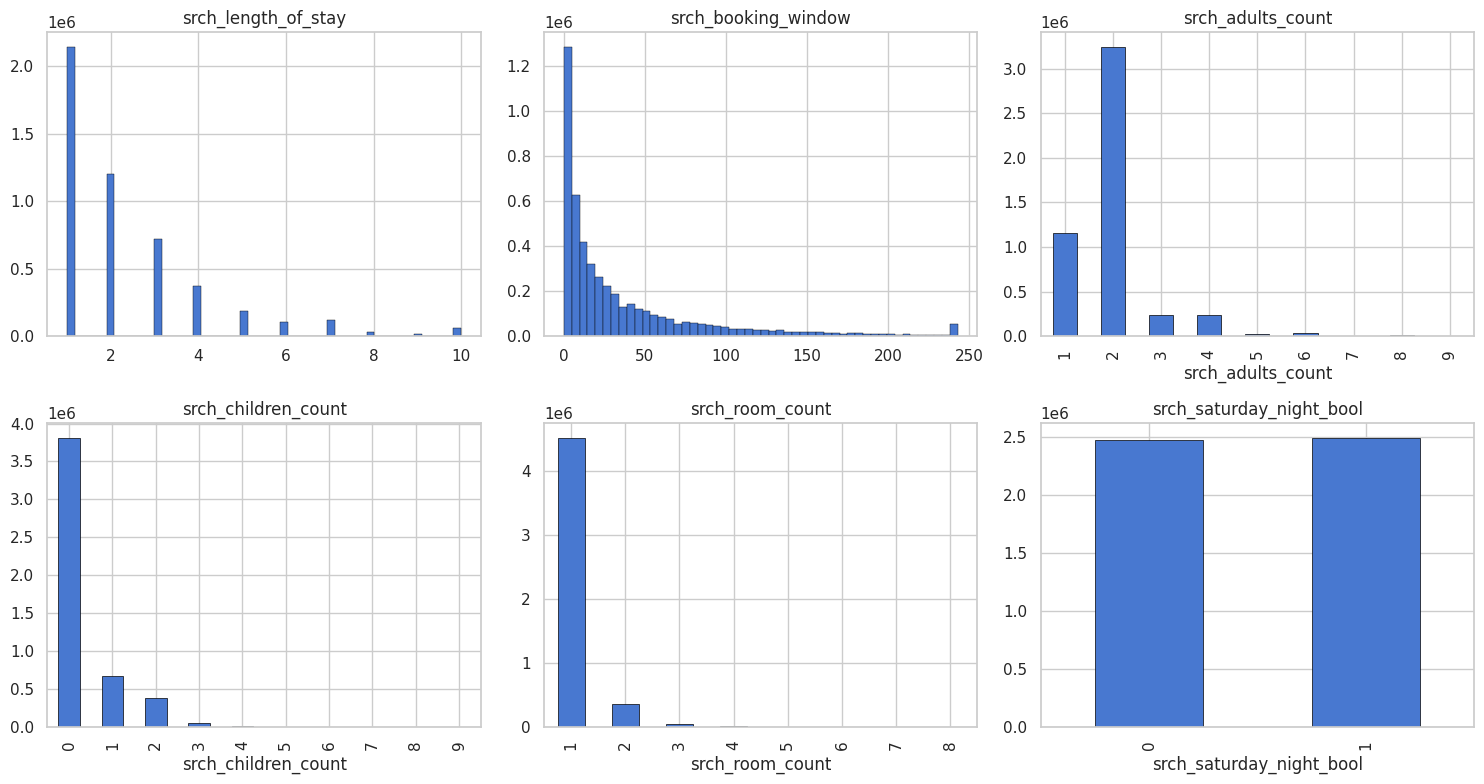

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, ["srch_length_of_stay", "srch_booking_window",
                                "srch_adults_count", "srch_children_count",
                                "srch_room_count", "srch_saturday_night_bool"]):
    if df[col].nunique() <= 15:
        df[col].value_counts().sort_index().plot.bar(ax=ax, edgecolor="black", linewidth=0.5)
    else:
        df[col].clip(upper=df[col].quantile(0.99)).hist(bins=50, ax=ax, edgecolor="black", linewidth=0.3)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### Other Features & ID Distributions

In [12]:
# Sparse / special features
print("random_bool value counts:")
print(df["random_bool"].value_counts())
print(f"\npromotion_flag value counts:")
print(df["promotion_flag"].value_counts())
print(f"\nsrch_query_affinity_score: {df['srch_query_affinity_score'].isnull().mean()*100:.1f}% null")
print(f"orig_destination_distance: {df['orig_destination_distance'].isnull().mean()*100:.1f}% null")

random_bool value counts:
random_bool
0    3491170
1    1467177
Name: count, dtype: int64

promotion_flag value counts:
promotion_flag
0    3889229
1    1069118
Name: count, dtype: int64

srch_query_affinity_score: 93.6% null
orig_destination_distance: 32.4% null


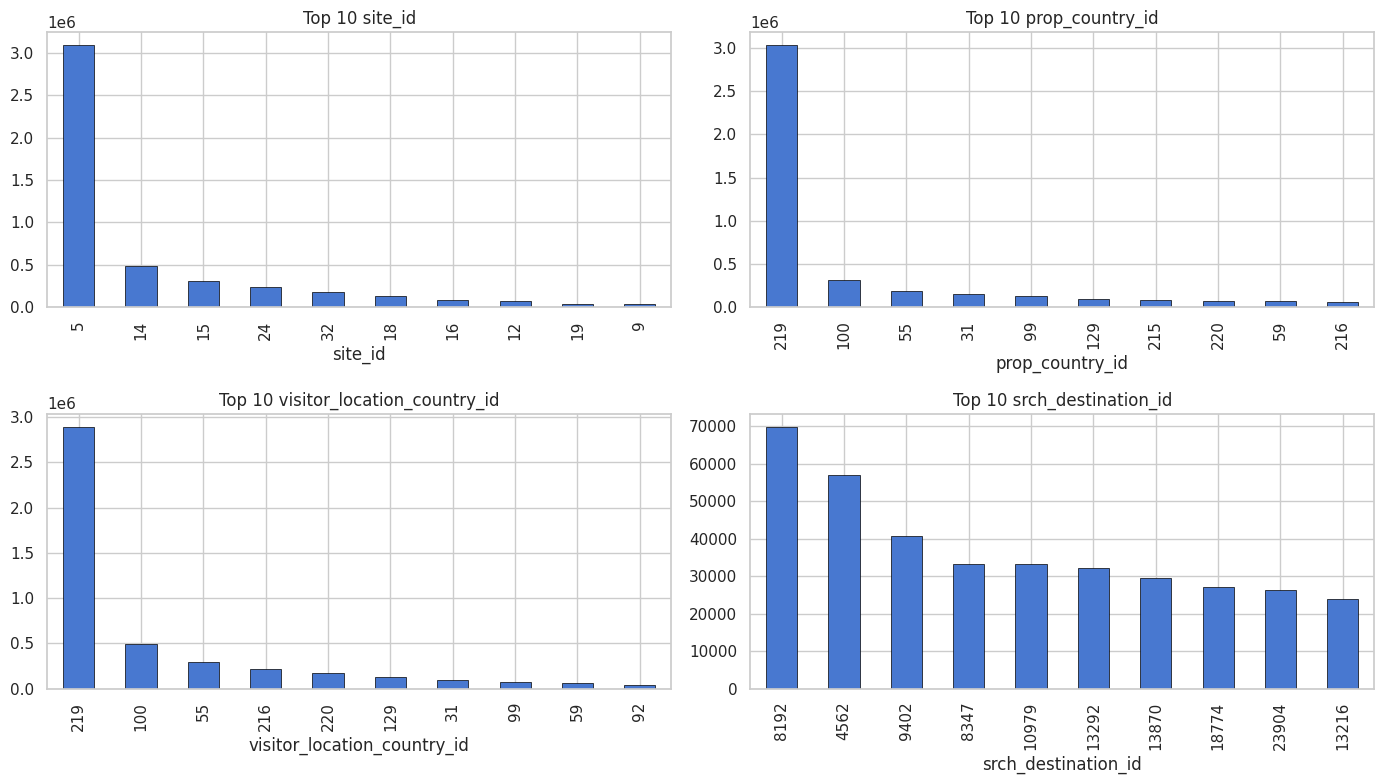

In [13]:
# Top-10 ID distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, ["site_id", "prop_country_id",
                                "visitor_location_country_id", "srch_destination_id"]):
    df[col].value_counts().head(10).plot.bar(ax=ax, edgecolor="black", linewidth=0.5)
    ax.set_title(f"Top 10 {col}")
plt.tight_layout()
plt.show()

## 4. Feature vs. Target Relationships

### Categorical Features vs. Booking/Click Rate

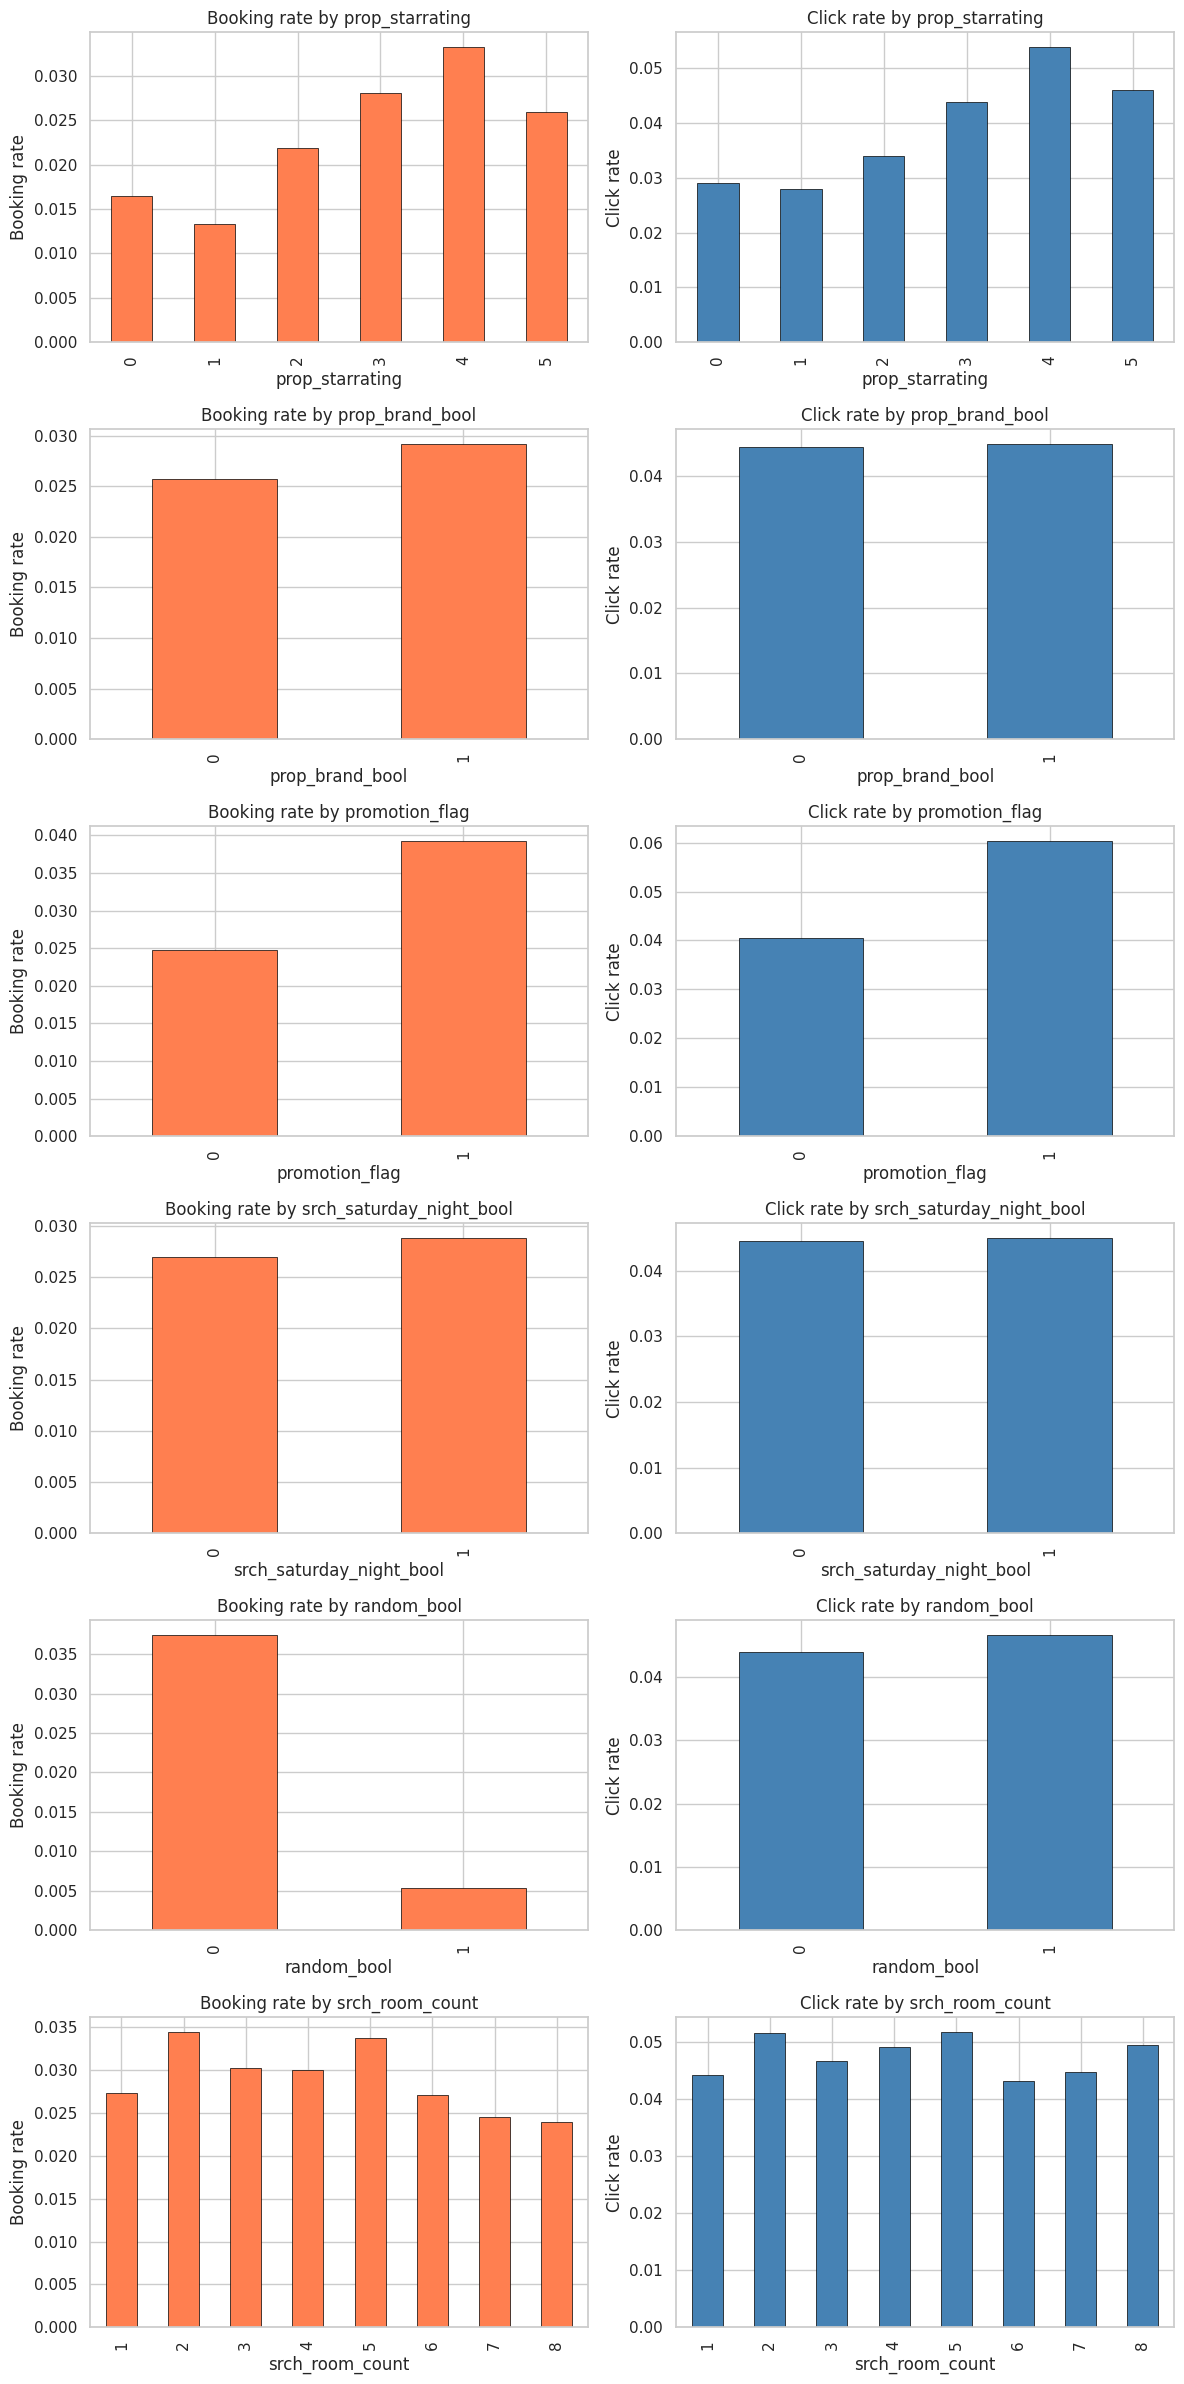

In [14]:
def plot_rates_by_group(df, group_col, axes_row):
    """Plot booking rate and click rate by a categorical grouping."""
    rates = df.groupby(group_col).agg(
        booking_rate=("booking_bool", "mean"),
        click_rate=("click_bool", "mean"),
        count=("booking_bool", "size"),
    )
    rates["booking_rate"].plot.bar(ax=axes_row[0], color="coral", edgecolor="black", linewidth=0.5)
    axes_row[0].set_title(f"Booking rate by {group_col}")
    axes_row[0].set_ylabel("Booking rate")
    rates["click_rate"].plot.bar(ax=axes_row[1], color="steelblue", edgecolor="black", linewidth=0.5)
    axes_row[1].set_title(f"Click rate by {group_col}")
    axes_row[1].set_ylabel("Click rate")

cat_features = [
    "prop_starrating", "prop_brand_bool", "promotion_flag",
    "srch_saturday_night_bool", "random_bool", "srch_room_count",
]

fig, axes = plt.subplots(len(cat_features), 2, figsize=(12, 4 * len(cat_features)))
for i, col in enumerate(cat_features):
    plot_rates_by_group(df, col, axes[i])
plt.tight_layout()
plt.show()

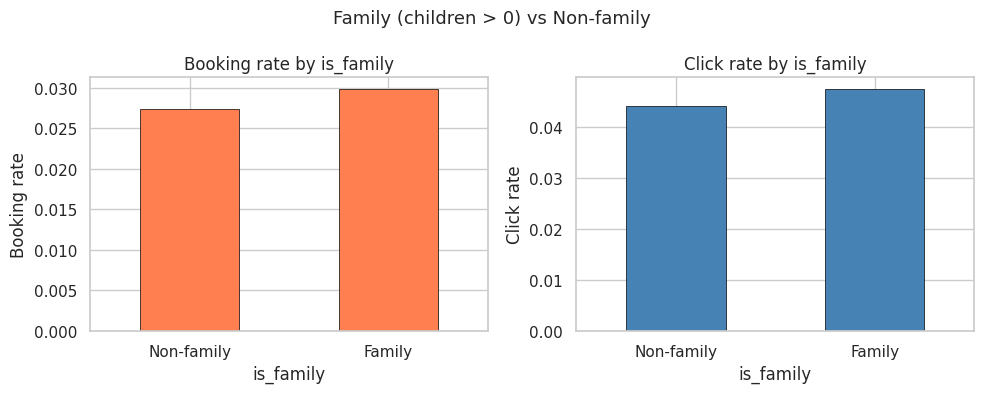

In [15]:
# Family vs. non-family (feeds bias investigation)
df["is_family"] = (df["srch_children_count"] > 0).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_rates_by_group(df, "is_family", axes)
axes[0].set_xticklabels(["Non-family", "Family"], rotation=0)
axes[1].set_xticklabels(["Non-family", "Family"], rotation=0)
plt.suptitle("Family (children > 0) vs Non-family", fontsize=13)
plt.tight_layout()
plt.show()

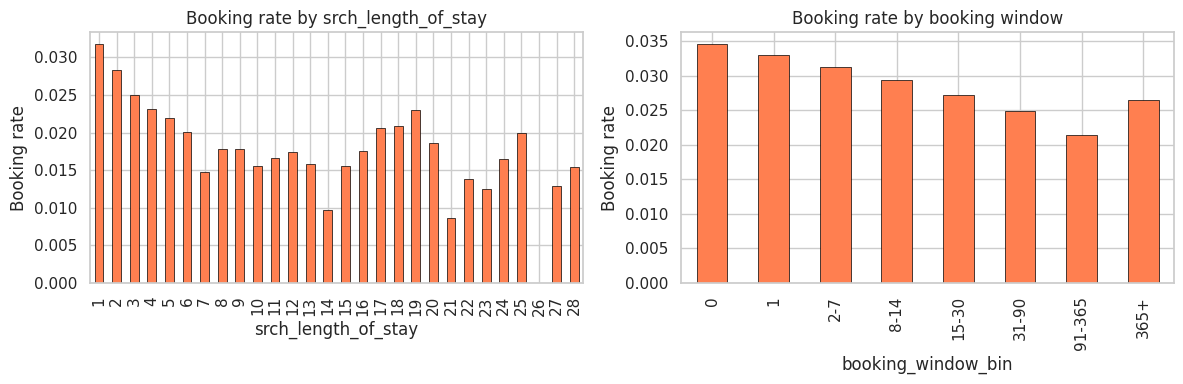

In [16]:
# Booking rate by srch_length_of_stay
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rates = df.groupby("srch_length_of_stay").agg(
    booking_rate=("booking_bool", "mean"), count=("booking_bool", "size")
)
rates = rates[rates["count"] >= 100]  # filter rare values
rates["booking_rate"].plot.bar(ax=axes[0], color="coral", edgecolor="black", linewidth=0.5)
axes[0].set_title("Booking rate by srch_length_of_stay")
axes[0].set_ylabel("Booking rate")

# Booking rate by srch_booking_window (binned)
df["booking_window_bin"] = pd.cut(
    df["srch_booking_window"],
    bins=[-1, 0, 1, 7, 14, 30, 90, 365, 9999],
    labels=["0", "1", "2-7", "8-14", "15-30", "31-90", "91-365", "365+"],
)
df.groupby("booking_window_bin", observed=True)["booking_bool"].mean().plot.bar(
    ax=axes[1], color="coral", edgecolor="black", linewidth=0.5
)
axes[1].set_title("Booking rate by booking window")
axes[1].set_ylabel("Booking rate")
plt.tight_layout()
plt.show()

### Continuous Features vs. Booking Rate (binned analysis)

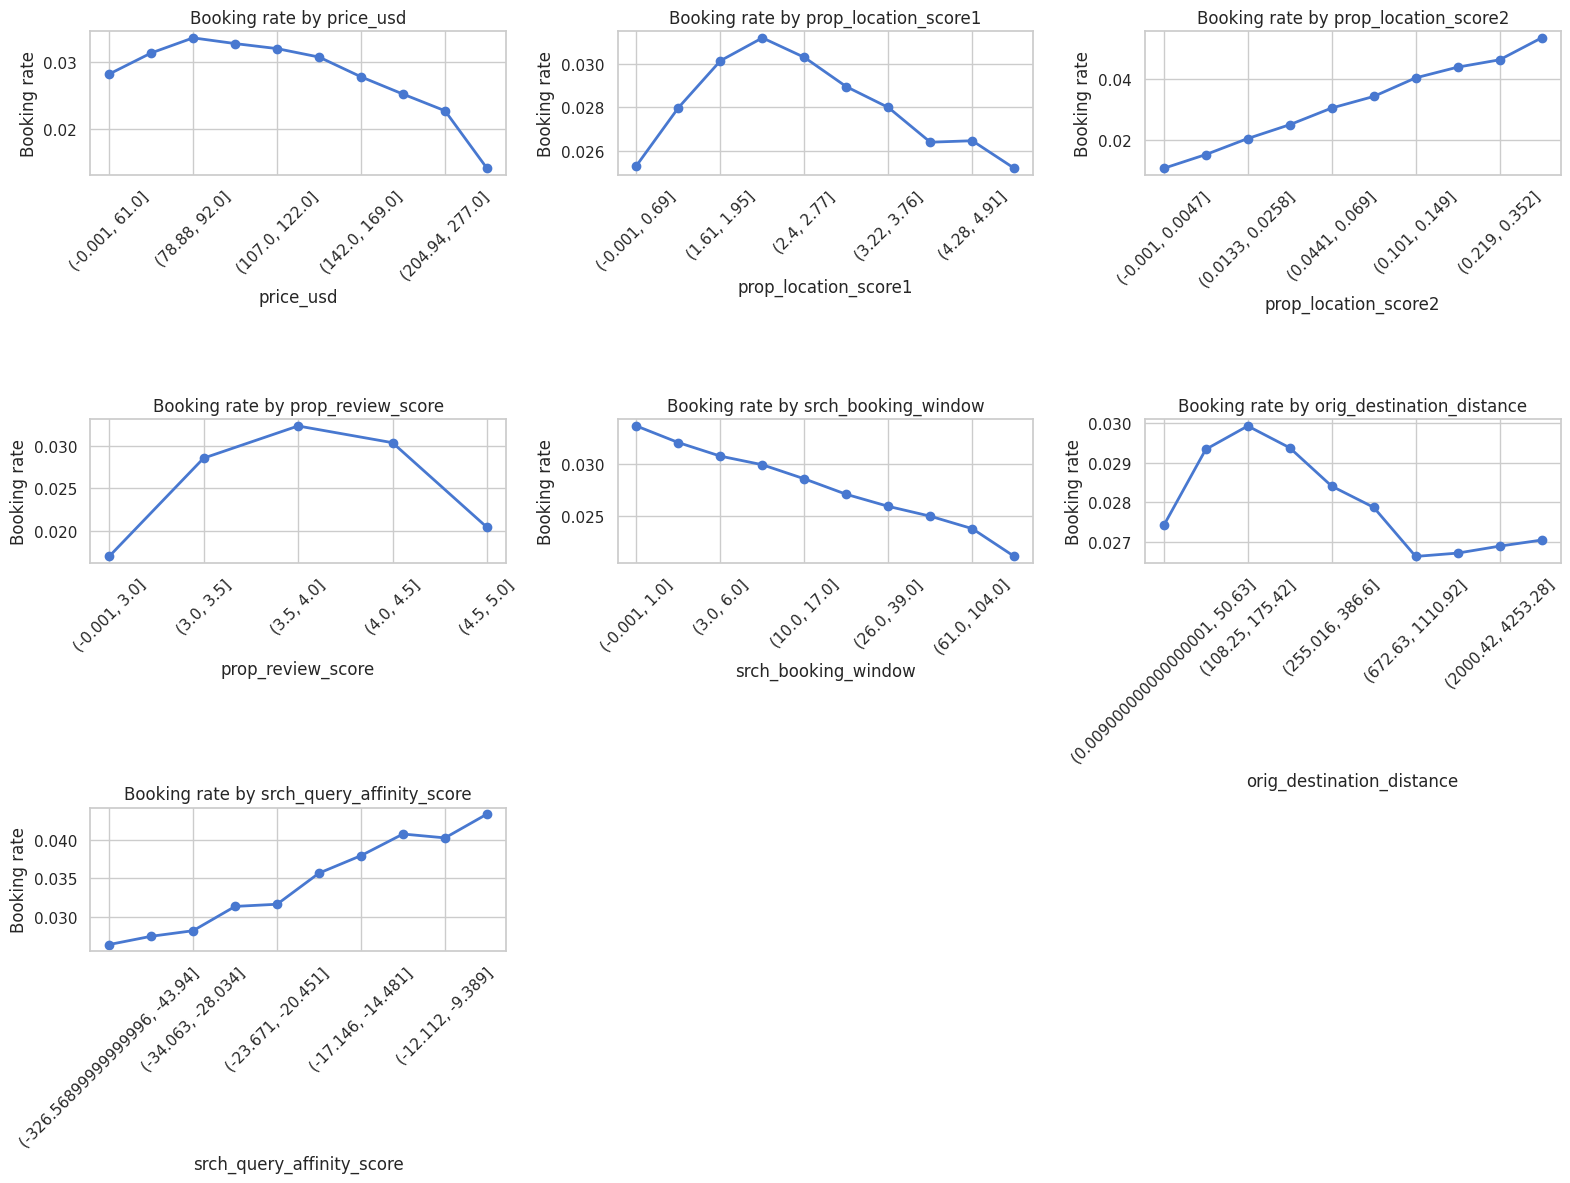

In [17]:
def plot_binned_booking_rate(df, col, n_bins=10, ax=None):
    """Bin a continuous feature into quantiles and plot booking rate per bin."""
    data = df[[col, "booking_bool"]].dropna()
    if len(data) < 100:
        return
    try:
        data["bin"] = pd.qcut(data[col], q=n_bins, duplicates="drop")
    except ValueError:
        return
    rates = data.groupby("bin", observed=True)["booking_bool"].mean()
    if ax is None:
        fig, ax = plt.subplots()
    rates.plot(ax=ax, marker="o", linewidth=2)
    ax.set_title(f"Booking rate by {col}")
    ax.set_ylabel("Booking rate")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45)

cont_features = [
    "price_usd", "prop_location_score1", "prop_location_score2",
    "prop_review_score", "srch_booking_window",
    "orig_destination_distance", "srch_query_affinity_score",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, cont_features):
    plot_binned_booking_rate(df, col, ax=ax)
# hide unused subplots
for ax in axes.flat[len(cont_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

`prop_starrating` shows a clear monotonic relationship with booking rate. `promotion_flag` roughly doubles the booking rate. Lower `price_usd` bins are booked more often — price sensitivity is strong. The `random_bool` sanity check confirms both groups have similar rates, validating the randomization. Family searches (children > 0) show a slightly different booking pattern, worth investigating for bias.

## 5. Correlation Matrix

In [18]:
# Exclude ID columns (categorical by nature)
exclude_ids = {"srch_id", "prop_id", "srch_destination_id", "site_id",
               "prop_country_id", "visitor_location_country_id"}
numeric_cols = [c for c in df.select_dtypes(include="number").columns if c not in exclude_ids]

corr = df[numeric_cols].corr()

# Top correlates with booking_bool and click_bool
print("Top correlates with booking_bool:")
print(corr["booking_bool"].drop(["booking_bool", "click_bool"]).sort_values(ascending=False).head(15).to_string())
print("\nTop correlates with click_bool:")
print(corr["click_bool"].drop(["booking_bool", "click_bool"]).sort_values(ascending=False).head(15).to_string())

Top correlates with booking_bool:
prop_location_score2         0.066405
promotion_flag               0.036047
prop_review_score            0.025800
srch_query_affinity_score    0.025524
comp8_rate                   0.023607
prop_starrating              0.021206
comp5_rate                   0.020827
comp4_rate                   0.017926
comp3_rate                   0.016315
comp2_rate                   0.016217
comp6_rate                   0.011455
comp7_rate                   0.011432
comp1_rate                   0.010133
prop_brand_bool              0.009991
srch_room_count              0.007948

Top correlates with click_bool:
prop_location_score2         0.073807
srch_query_affinity_score    0.041764
promotion_flag               0.039440
prop_starrating              0.030788
comp8_rate                   0.023658
prop_review_score            0.023424
comp5_rate                   0.021434
comp4_rate                   0.018166
comp2_rate                   0.016951
comp3_rate           

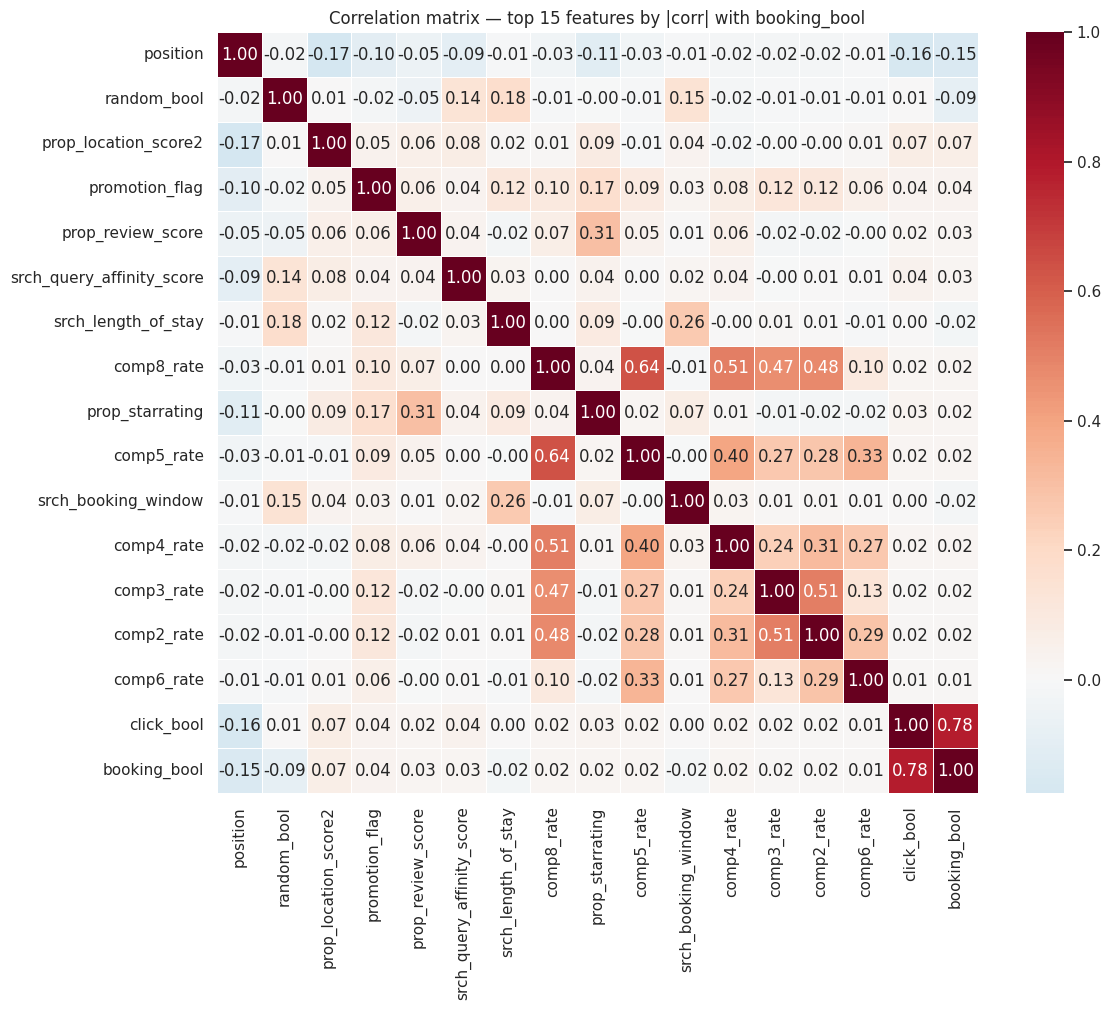

In [19]:
# Heatmap of top 15 features most correlated with booking_bool
top_features = (
    corr["booking_bool"]
    .drop(["booking_bool", "click_bool"])
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)
top_features_with_targets = top_features + ["click_bool", "booking_bool"]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr.loc[top_features_with_targets, top_features_with_targets],
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
    square=True, linewidths=0.5,
)
ax.set_title("Correlation matrix — top 15 features by |corr| with booking_bool")
plt.tight_layout()
plt.show()

## Summary

**Dataset scale:** 4,958,347 rows across 199,795 searches. Each search contains 5–38 hotels (median 29, mean ~25).

**Target class imbalance:** Booking rate is 2.79%, click rate is 4.47%. 62.4% of clicks lead to a booking. Every booking is also a click (confirmed). Most hotels per search have relevance 0 — extreme imbalance that ranking models must handle.

**Most predictive features** (from correlation + binned analysis):
- `prop_location_score2` — strongest single correlate with booking (r=0.066)
- `promotion_flag` — promoted hotels booked at higher rate (r=0.036)
- `prop_review_score` — higher reviews → more bookings (r=0.026)
- `srch_query_affinity_score` — strong signal but 93% null
- `prop_starrating` — monotonically increasing booking rate with stars
- `price_usd` — lower price bins have higher booking rates

**Null patterns:**
- Visitor history (`visitor_hist_starrating`, `visitor_hist_adr_usd`): ~95% null — most users are first-time visitors with no purchase history. Nullness itself is likely informative.
- Competitor columns: 55–98% null depending on competitor. Too sparse individually, should be aggregated.
- `srch_query_affinity_score`: 93% null. When present, strongly predictive.
- `orig_destination_distance`: 33% null. Likely missing for international or unresolved locations.

**Surprises / anomalies:**
- `random_bool` split is roughly 50/50 — booking and click rates are similar across both groups, confirming clean randomization.
- `prop_log_historical_price` has a notable fraction of zeros, meaning the hotel had no prior sales data.

In [20]:
# Clean up temp columns
df.drop(columns=["is_family", "booking_window_bin"], inplace=True, errors="ignore")
print("EDA complete.")

EDA complete.
